# IMPORTING LIBRARIES

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
pd.set_option('display.max_columns', None)

# LOADING THE DATASET

In [3]:
raw_data = pd.read_csv(r"C:\Users\USER\Downloads\Phone Link\nigerian_retail_and_ecommerce_customer_segmentation_data.csv")

In [4]:
raw_data

,customer_id,segment,avg_order_value_ngn,purchase_frequency,total_orders,total_spend_ngn,last_purchase_days_ago,churn_risk,lifetime_value_ngn,preferred_category,seasonal_buyer
0,CUST822847,mid_tier,152200.92,medium,77,115658.71,141,low,1731792.76,Fashion,False
1,CUST928064,mid_tier,136582.83,medium,69,180661.70,143,medium,261129.27,Health,True
2,CUST221451,high_value,388564.36,medium,51,276543.46,51,low,2537201.91,Home & Living,False
3,CUST986193,premium,4344955.62,high,69,3746437.97,167,medium,4180414.32,Books & Media,True
4,CUST422305,high_value,385518.17,medium,21,393956.62,35,low,4656929.32,Health,True
...,...,...,...,...,...,...,...,...,...,...,...
149995,CUST322735,high_value,311837.05,medium,78,330034.49,142,low,199993.10,Fashion,True
149996,CUST415491,mid_tier,108872.81,medium,6,162833.66,134,low,4538967.34,Baby & Kids,False
149997,CUST716767,mid_tier,87869.99,medium,91,124957.47,240,high,3356665.50,Books & Media,False
149998,CUST306740,budget,37286.22,low,27,45403.50,86,medium,2080698.72,Baby & Kids,False


# EDA and DATA PREPROCESSING 

In [5]:
raw_data.shape

(150000, 11)

In [6]:
raw_data.columns

Index(['customer_id', 'segment', 'avg_order_value_ngn', 'purchase_frequency',
       'total_orders', 'total_spend_ngn', 'last_purchase_days_ago',
       'churn_risk', 'lifetime_value_ngn', 'preferred_category',
       'seasonal_buyer'],
      dtype='object')

In [7]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   customer_id             150000 non-null  object 
 1   segment                 150000 non-null  object 
 2   avg_order_value_ngn     150000 non-null  float64
 3   purchase_frequency      150000 non-null  object 
 4   total_orders            150000 non-null  int64  
 5   total_spend_ngn         150000 non-null  float64
 6   last_purchase_days_ago  150000 non-null  int64  
 7   churn_risk              150000 non-null  object 
 8   lifetime_value_ngn      150000 non-null  float64
 9   preferred_category      150000 non-null  object 
 10  seasonal_buyer          150000 non-null  bool   
dtypes: bool(1), float64(3), int64(2), object(5)
memory usage: 11.6+ MB


In [8]:
raw_data.describe()

,avg_order_value_ngn,total_orders,total_spend_ngn,last_purchase_days_ago,lifetime_value_ngn
count,1.500000e+05,150000.000000,1.500000e+05,150000.000000,1.500000e+05
mean,4.023700e+05,50.524267,4.029449e+05,182.765813,2.506594e+06
std,8.912618e+05,28.931225,8.914190e+05,105.406089,1.439000e+06
min,1.000320e+03,1.000000,1.000770e+03,1.000000,1.000376e+04
25%,4.196790e+04,25.000000,4.207008e+04,92.000000,1.260718e+06
50%,1.248351e+05,50.000000,1.248436e+05,182.000000,2.508156e+06
75%,2.753824e+05,76.000000,2.741794e+05,274.000000,3.745314e+06
max,4.999992e+06,100.000000,4.999947e+06,365.000000,4.999991e+06


In [9]:
raw_data.describe(include = 'object')

,customer_id,segment,purchase_frequency,churn_risk,preferred_category
count,150000,150000,150000,150000,150000
unique,138034,5,4,3,10
top,CUST978900,mid_tier,medium,low,Baby & Kids
freq,5,60080,90099,89646,15096


In [10]:
raw_data.isnull().sum()

customer_id               0
segment                   0
avg_order_value_ngn       0
purchase_frequency        0
total_orders              0
total_spend_ngn           0
last_purchase_days_ago    0
churn_risk                0
lifetime_value_ngn        0
preferred_category        0
seasonal_buyer            0
dtype: int64

In [11]:
raw_data.duplicated().sum()

np.int64(0)

In [12]:
data_preprocess = raw_data.drop(columns = ['customer_id', 'segment', 'churn_risk'])

In [13]:
data_preprocess.head()

,avg_order_value_ngn,purchase_frequency,total_orders,total_spend_ngn,last_purchase_days_ago,lifetime_value_ngn,preferred_category,seasonal_buyer
0,152200.92,medium,77,115658.71,141,1731792.76,Fashion,False
1,136582.83,medium,69,180661.70,143,261129.27,Health,True
2,388564.36,medium,51,276543.46,51,2537201.91,Home & Living,False
3,4344955.62,high,69,3746437.97,167,4180414.32,Books & Media,True
4,385518.17,medium,21,393956.62,35,4656929.32,Health,True


In [14]:
data_preprocess.columns

Index(['avg_order_value_ngn', 'purchase_frequency', 'total_orders',
       'total_spend_ngn', 'last_purchase_days_ago', 'lifetime_value_ngn',
       'preferred_category', 'seasonal_buyer'],
      dtype='object')

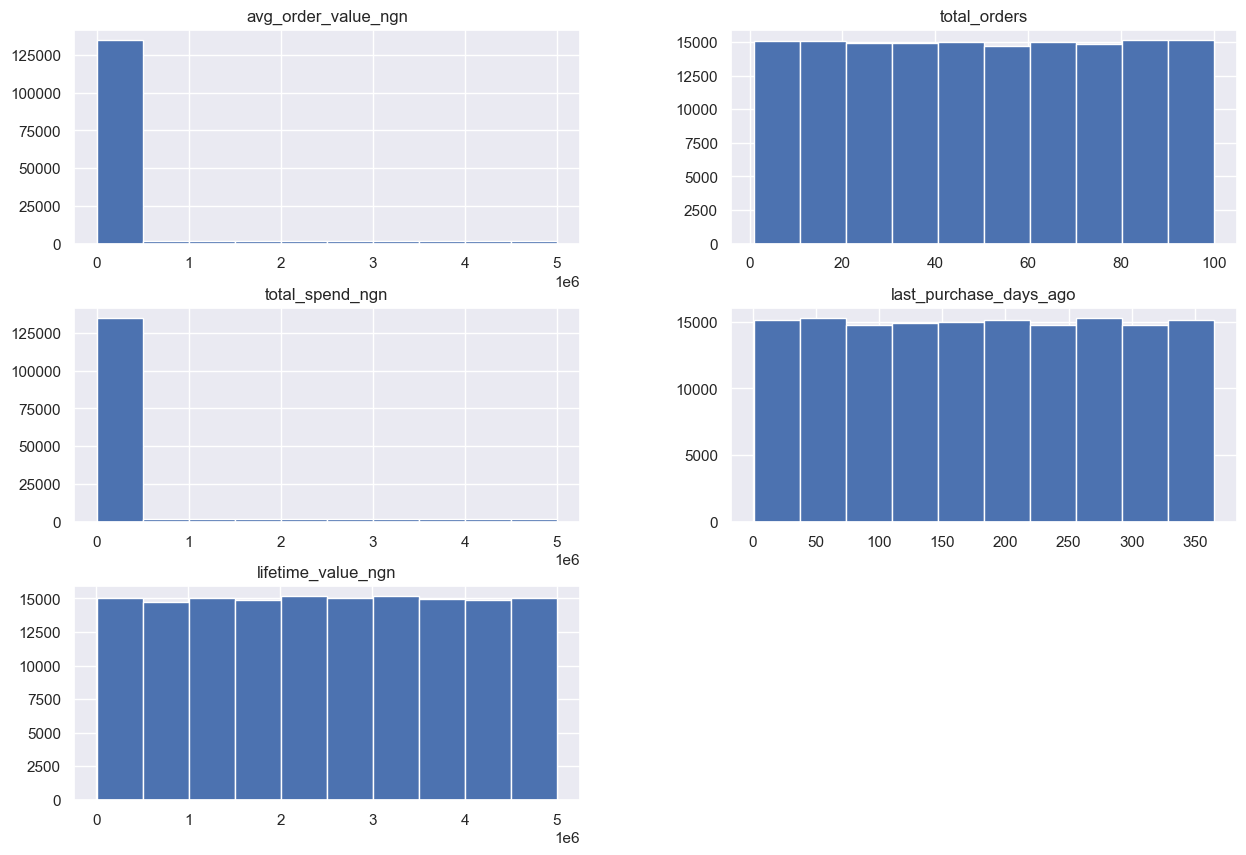

In [15]:
data_preprocess.hist(figsize = (15,10))
plt.show()

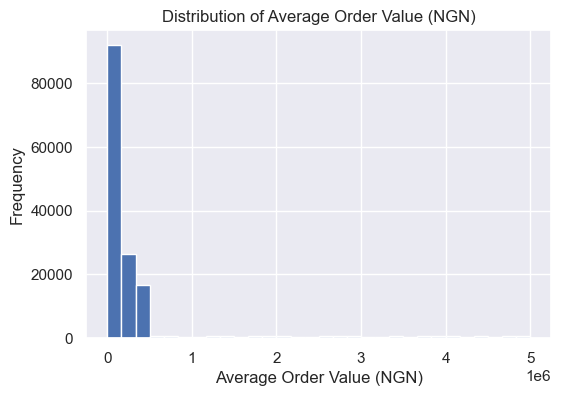

In [16]:
plt.figure(figsize = (6,4))
data_preprocess['avg_order_value_ngn'].hist(bins = 30)
plt.title('Distribution of Average Order Value (NGN)')
plt.xlabel('Average Order Value (NGN)')
plt.ylabel('Frequency')
plt.show()

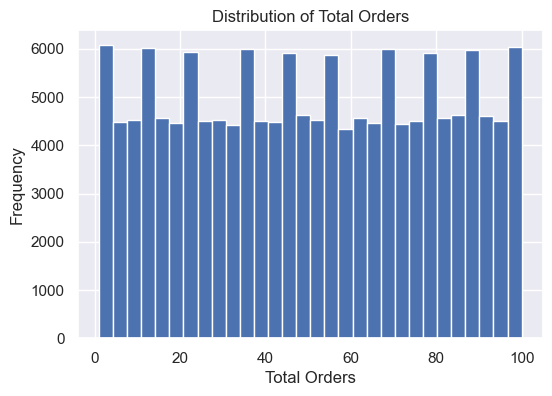

In [17]:
plt.figure(figsize = (6,4))
data_preprocess['total_orders'].hist(bins = 30)
plt.title('Distribution of Total Orders')
plt.xlabel('Total Orders')
plt.ylabel('Frequency')
plt.show()

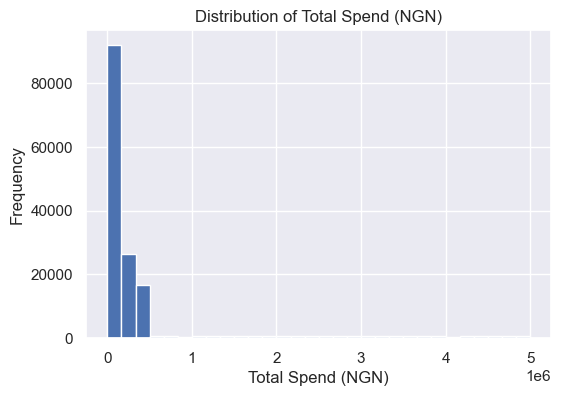

In [18]:
plt.figure(figsize = (6,4))
data_preprocess['total_spend_ngn'].hist(bins = 30)
plt.title('Distribution of Total Spend (NGN)')
plt.xlabel('Total Spend (NGN)')
plt.ylabel('Frequency')
plt.show()

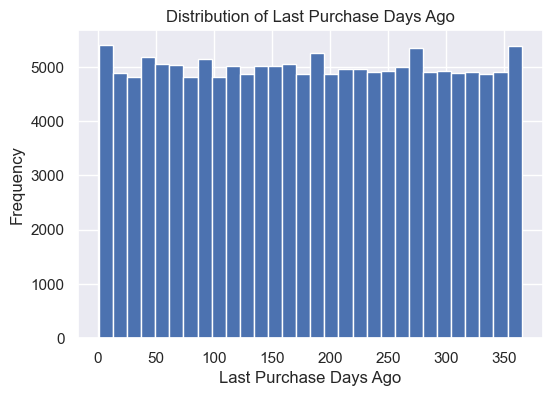

In [19]:
plt.figure(figsize = (6,4))
data_preprocess['last_purchase_days_ago'].hist(bins = 30)
plt.title('Distribution of Last Purchase Days Ago')
plt.xlabel('Last Purchase Days Ago')
plt.ylabel('Frequency')
plt.show()

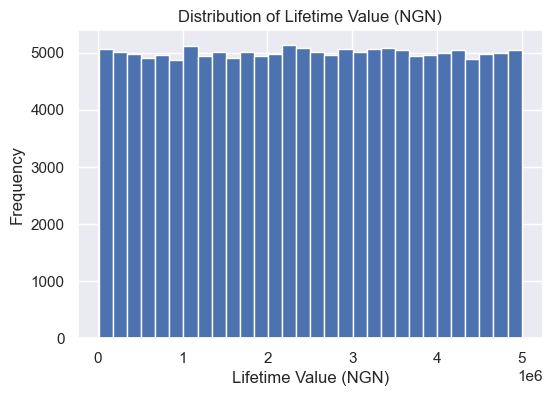

In [20]:
plt.figure(figsize = (6,4))
data_preprocess['lifetime_value_ngn'].hist(bins = 30)
plt.title('Distribution of Lifetime Value (NGN)')
plt.xlabel('Lifetime Value (NGN)')
plt.ylabel('Frequency')
plt.show()

The distribution show the spread and frequency of the numerical variables. some variables exhibit skewness and the presence of extreme values, which will be considered during the preprocessing stage.

# BOX PLOT

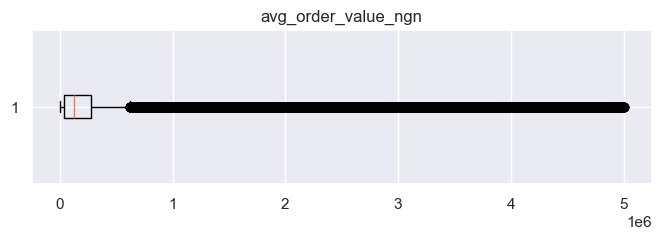

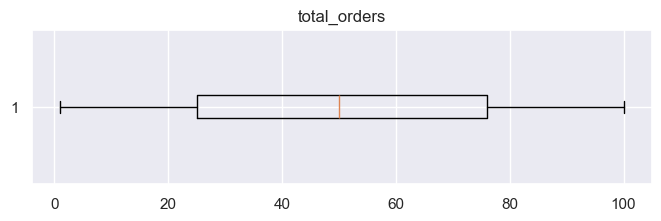

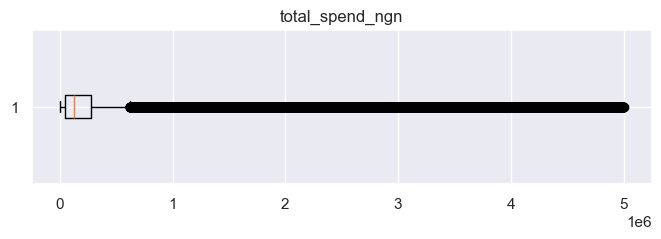

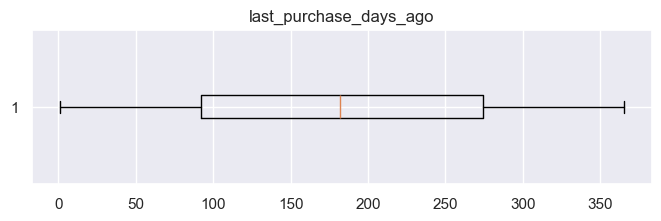

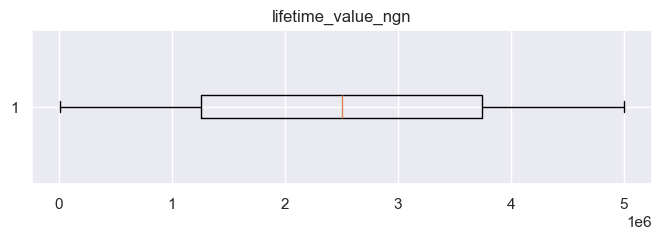

In [21]:
numerical_cols = ['avg_order_value_ngn', 'total_orders', 'total_spend_ngn', 'last_purchase_days_ago', 'lifetime_value_ngn']
for col in numerical_cols:
    plt.figure(figsize = (8,2))
    plt.boxplot(data_preprocess[col], vert = False)
    plt.title(col)
    plt.show()

The boxplots reveal potential outliers in several numerical variables. these observations were futher investigated to determine whether they represent genuine customers behavior or data anomalies.

# CHECKING THE CATEGORICAL VARIABLES

In [22]:
data_preprocess['purchase_frequency'].value_counts()

purchase_frequency
medium      90099
low         37406
high        14992
very_low     7503
Name: count, dtype: int64

In [23]:
data_preprocess['preferred_category'].value_counts()

preferred_category
Baby & Kids               15096
Beauty & Personal Care    15045
Books & Media             15040
Home & Living             15015
Fashion                   15003
Sports & Outdoors         14973
Groceries                 14970
Electronics               14964
Automotive                14960
Health                    14934
Name: count, dtype: int64

In [24]:
data_preprocess['seasonal_buyer'].value_counts()

seasonal_buyer
False    90026
True     59974
Name: count, dtype: int64

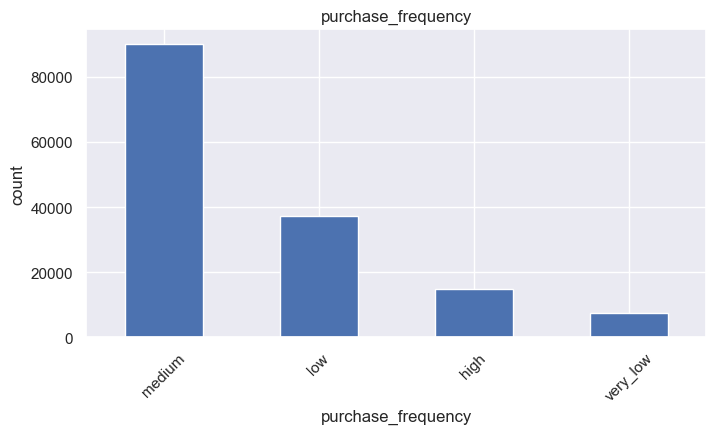

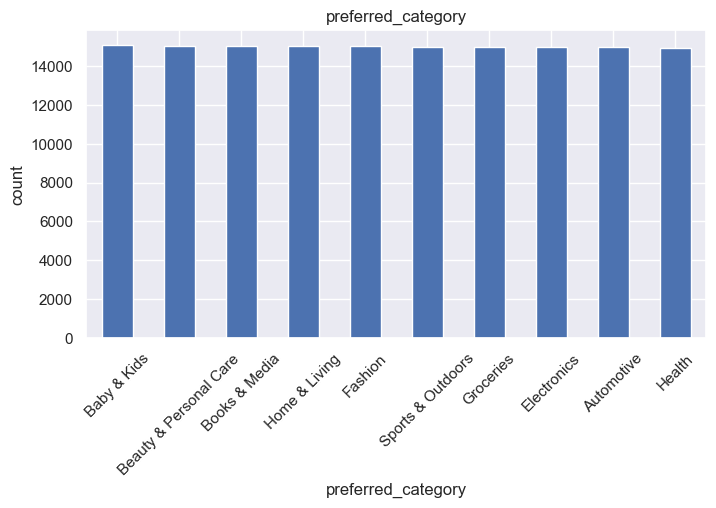

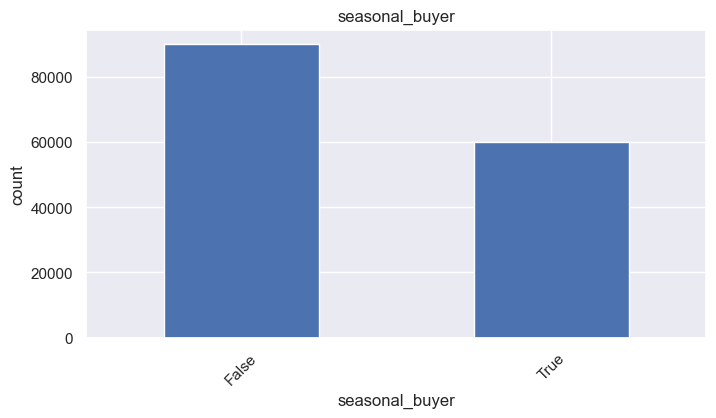

In [25]:
categorical_cols = ['purchase_frequency', 'preferred_category', 'seasonal_buyer']

for col in categorical_cols:
    plt.figure(figsize = (8,4))
    data_preprocess[col].value_counts().plot(kind = 'bar')
    plt.title(col)
    plt.ylabel('count')
    plt.xticks(rotation = 45)
    plt.show()


# CORRELATION ANALYSIS

In [26]:
corr = data_preprocess.select_dtypes(include = 'number').corr()

In [27]:
corr

,avg_order_value_ngn,total_orders,total_spend_ngn,last_purchase_days_ago,lifetime_value_ngn
avg_order_value_ngn,1.000000,-0.002434,0.786726,0.001231,0.001486
total_orders,-0.002434,1.000000,-0.002536,0.001805,0.000065
total_spend_ngn,0.786726,-0.002536,1.000000,0.002229,0.000648
last_purchase_days_ago,0.001231,0.001805,0.002229,1.000000,0.005299
lifetime_value_ngn,0.001486,0.000065,0.000648,0.005299,1.000000


# CORRELATION PLOT

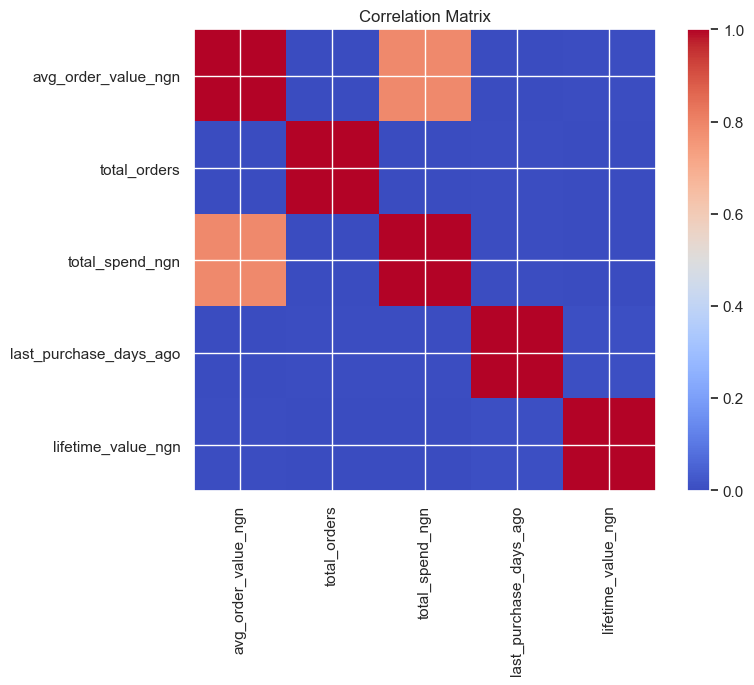

In [28]:
plt.figure(figsize = (8,6))
plt.imshow(corr, cmap = 'coolwarm')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation = 90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title('Correlation Matrix')
plt.show()

# CALCULATING THE NUMBERS OF OUTLIERS USING THE IQR METHOD

In [29]:
numerical_cols = ['avg_order_value_ngn', 'total_orders', 'total_spend_ngn', 'last_purchase_days_ago', 'lifetime_value_ngn']


for col in numerical_cols:
    Q1 = data_preprocess[col].quantile(0.25)
    Q3 = data_preprocess[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data_preprocess[(data_preprocess[col] < lower_bound) | (data_preprocess[col] > upper_bound)]

    print(f'{col}:{len(outliers)} outliers')

avg_order_value_ngn:14584 outliers
total_orders:0 outliers
total_spend_ngn:14604 outliers
last_purchase_days_ago:0 outliers
lifetime_value_ngn:0 outliers


The correlation matrix shows the relationship between the numerical variables. strong correlation indicate variables the tend to change together, while weak correlations suggest limited linear relationships.

# DEALING WITH OUTLIERS

In [30]:
for col in ['avg_order_value_ngn', 'total_spend_ngn']:
    data_preprocess[col] = np.log1p(data_preprocess[col])

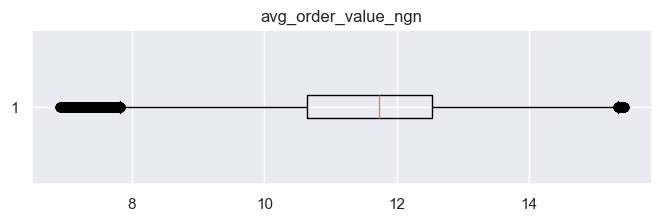

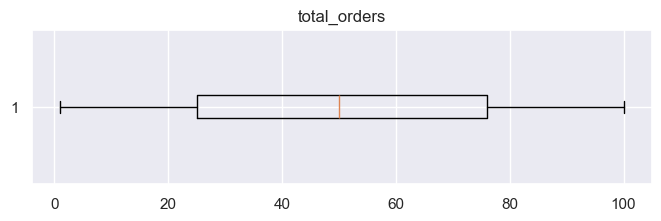

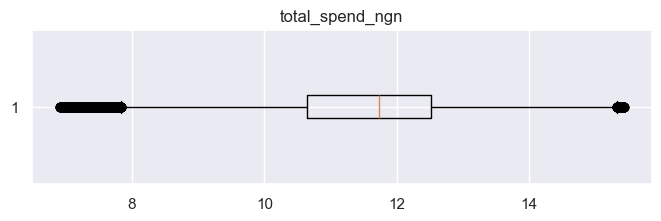

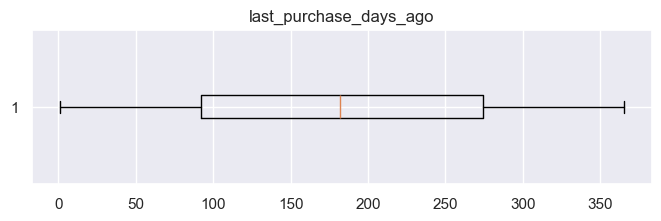

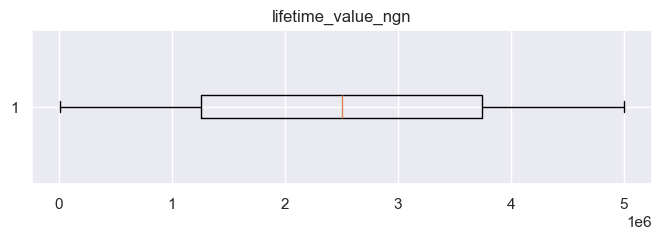

In [31]:
numerical_cols = data_preprocess.select_dtypes(include = 'number').columns

for col in numerical_cols:
    plt.figure(figsize = (8,2))
    plt.boxplot(data_preprocess[col], vert = False)
    plt.title(col)
    plt.show()

In [32]:
numerical_cols = ['avg_order_value_ngn', 'total_orders', 'total_spend_ngn', 'last_purchase_days_ago', 'lifetime_value_ngn']


for col in numerical_cols:
    Q1 = data_preprocess[col].quantile(0.25)
    Q3 = data_preprocess[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data_preprocess[(data_preprocess[col] < lower_bound) | (data_preprocess[col] > upper_bound)]

    print(f'{col}:{len(outliers)} outliers')

avg_order_value_ngn:2521 outliers
total_orders:0 outliers
total_spend_ngn:2740 outliers
last_purchase_days_ago:0 outliers
lifetime_value_ngn:0 outliers


# SEPERATING NUMERICAL AND CATEGORICAL COLUMNS

In [33]:
numerical_cols = ['avg_order_value_ngn', 'total_orders', 'total_spend_ngn', 'last_purchase_days_ago', 'lifetime_value_ngn']

categorical_cols = ['purchase_frequency', 'preferred_category', 'seasonal_buyer']

# CONVERTING CATEGORICAL VARIABLE TO CATEGORICAL TYPE

In [34]:
for col in categorical_cols:
    data_preprocess[col] = data_preprocess[col].astype('category')

# SCALING THE NUMERICAL VARIABLES

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

data_preprocess[numerical_cols] = scaler.fit_transform(data_preprocess[numerical_cols])

In [36]:
data_preprocess.dtypes

avg_order_value_ngn        float64
purchase_frequency        category
total_orders               float64
total_spend_ngn            float64
last_purchase_days_ago     float64
lifetime_value_ngn         float64
preferred_category        category
seasonal_buyer            category
dtype: object

# CONVERTING THE DATAFRAME TO A NUMPY ARRAY

In [37]:
x = data_preprocess[numerical_cols + categorical_cols].to_numpy()

# POSITIONING THE CATEGORICAL COLUMNS

In [38]:
categorical_index = [5,6,7]

The numerical variables were transformed and scaled where appropriate, while categorical variables were prepared for clustering. this ensures that variables with different scaled do not disproportionately influence the clustering process

# CLUSTERING

# IMPORTING KPROTOTYPE

In [39]:
!pip install kmodes

In [40]:
from kmodes.kprototypes import KPrototypes

# FINDING OPTIMAL NUMBER OF CLUSTERS

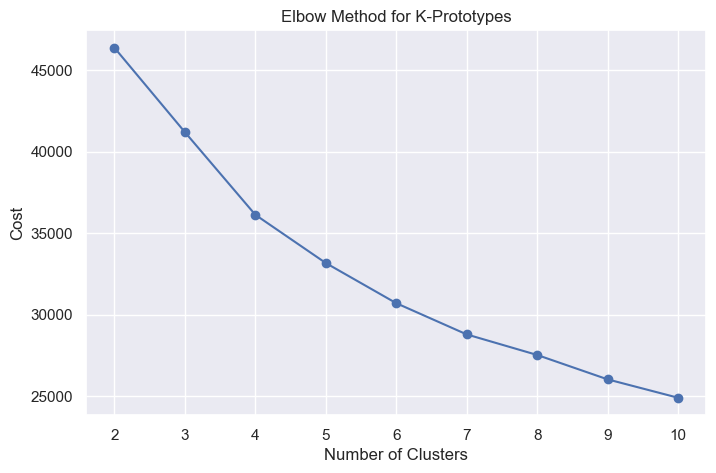

In [41]:
sample = data_preprocess.sample(n=10000, random_state=42)
x_sample = sample[numerical_cols + categorical_cols].to_numpy()


cost = []
K_range = range(2,11)
for k in K_range:
    kproto = KPrototypes(n_clusters = k, init = 'Huang', random_state = 42, n_init = 1, max_iter = 20)
    kproto.fit_predict(x_sample, categorical = categorical_index)
    cost.append(kproto.cost_)

plt.figure(figsize = (8,5))
plt.plot(range(2,11),cost, marker = 'o')
plt.xlabel('Number of Clusters')
plt.ylabel('Cost')
plt.title('Elbow Method for K-Prototypes')
plt.show()

The evaluation of different numbers of cluster was used to determine an appropriate number of customer segments. four clusters were selected as the most suitable solution for this analysis

# FITTING THE FINAL K-PROTOTYPES MODEL USING 4 CLUSTERS

In [42]:
kproto = KPrototypes(n_clusters = 4, init = 'Huang', n_init = 1, random_state = 42, verbose = 2)
clusters = kproto.fit_predict(data_preprocess[numerical_cols + categorical_cols].to_numpy(), categorical = categorical_index)

data_preprocess['Cluster'] = clusters

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 44337, ncost: 593097.7706707706
Run: 1, iteration: 2/100, moves: 19319, ncost: 584048.6968198714
Run: 1, iteration: 3/100, moves: 12904, ncost: 577624.9953033522
Run: 1, iteration: 4/100, moves: 9674, ncost: 574522.1537622102
Run: 1, iteration: 5/100, moves: 7806, ncost: 572175.6310282479
Run: 1, iteration: 6/100, moves: 8665, ncost: 568127.8949892942
Run: 1, iteration: 7/100, moves: 13643, ncost: 553078.01903996
Run: 1, iteration: 8/100, moves: 12746, ncost: 542925.1931113674
Run: 1, iteration: 9/100, moves: 5780, ncost: 541348.3314164904
Run: 1, iteration: 10/100, moves: 3164, ncost: 540861.793945985
Run: 1, iteration: 11/100, moves: 1747, ncost: 540719.1040163162
Run: 1, iteration: 12/100, moves: 986, ncost: 540676.6122646051
Run: 1, iteration: 13/100, moves: 540, ncost: 540664.1950174739
Run: 1, iteration: 14/100, moves: 250, ncost: 540662.3939858495
Run: 1, iteration: 1

# CLUSTER SIZES AND PROFILING

In [43]:
print(data_preprocess['Cluster'].value_counts())
print(data_preprocess['Cluster'].value_counts(normalize = True) * 100)

Cluster
3    45844
1    45833
0    43416
2    14907
Name: count, dtype: int64
Cluster
3    30.562667
1    30.555333
0    28.944000
2     9.938000
Name: proportion, dtype: float64


# PROFILING

In [44]:
numerical_profile = data_preprocess.groupby('Cluster')[numerical_cols].mean()
print(numerical_profile)

         avg_order_value_ngn  total_orders  total_spend_ngn  \
Cluster                                                       
0                  -1.148528      0.002762        -1.147178   
1                   0.223521      0.878722         0.222194   
2                   1.977073     -0.010912         1.980448   
3                   0.221352     -0.877579         0.220302   

         last_purchase_days_ago  lifetime_value_ngn  
Cluster                                              
0                      0.006605           -0.000349  
1                     -0.004119           -0.001879  
2                      0.009875            0.007110  
3                     -0.005348           -0.000103  


In [45]:
for col in categorical_cols:
    print(f'\n---{col}---')
    print(data_preprocess.groupby('Cluster')[col].agg(lambda x: x.mode()[0]))


---purchase_frequency---
Cluster
0       low
1    medium
2      high
3    medium
Name: purchase_frequency, dtype: category
Categories (4, object): ['high', 'low', 'medium', 'very_low']

---preferred_category---
Cluster
0         Health
1    Electronics
2     Automotive
3      Groceries
Name: preferred_category, dtype: category
Categories (10, object): ['Automotive', 'Baby & Kids', 'Beauty & Personal Care', 'Books & Media', ..., 'Groceries', 'Health', 'Home & Living', 'Sports & Outdoors']

---seasonal_buyer---
Cluster
0    False
1    False
2    False
3    False
Name: seasonal_buyer, dtype: category
Categories (2, bool): [False, True]


This profiling analysis compares the characteristics of each cluster across spending behavior, purchase frquency, customer demographics, and other relevant variables. these differences provide the basis for assigning meaningful descriptive names to the clusters.

# FULL DISTRIBUTION OF A CATEGORICAL COLUMN PER CLUSTER

In [46]:
for col in categorical_cols:
    print(f'\n---{col}---')
    print(pd.crosstab(data_preprocess['Cluster'], data_preprocess[col], normalize = 'index') * 100)



---purchase_frequency---
purchase_frequency        high        low     medium   very_low
Cluster                                                        
0                     0.000000  82.515662   0.202690  17.281647
1                     0.106910   1.647285  98.245805   0.000000
2                   100.000000   0.000000   0.000000   0.000000
3                     0.078527   1.801762  98.119710   0.000000

---preferred_category---
preferred_category  Automotive  Baby & Kids  Beauty & Personal Care  \
Cluster                                                               
0                    10.129906    10.178275               10.093053   
1                     9.833526    10.285166                9.818253   
2                    10.370967     9.874556                9.834306   
3                     9.835529     9.796266               10.245616   

preferred_category  Books & Media  Electronics    Fashion  Groceries  \
Cluster                                                          

# VALIDATING AGAINST THE EXISTING SEGMENT COLUMN

In [47]:
from sklearn.metrics import adjusted_rand_score

In [48]:
crosstab_result = pd.crosstab(data_preprocess['Cluster'], raw_data['segment'])
print(crosstab_result)

segment  budget  high_value  mid_tier  occasional  premium
Cluster                                                   
0         35825           0        88        7503        0
1           755       15015     30014           0       49
2             0           0         0           0    14907
3           826       15004     29978           0       36


# ADJUSTED RAND INDEX, MEASURES AGREEMENT BETWEEN THE TWO LABELINGS

In [49]:
ari_score = adjusted_rand_score(raw_data['segment'], data_preprocess['Cluster'])
print(f'Adjusted Rand Index: {ari_score:.4f}')

Adjusted Rand Index: 0.4601


# VISUALIZATION

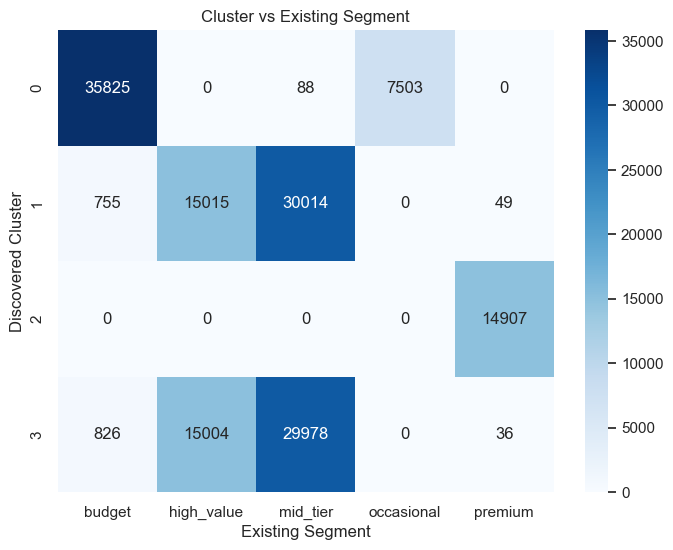

In [50]:
plt.figure(figsize = (8,6))
sns.heatmap(crosstab_result, annot = True, fmt = 'd', cmap = 'Blues')
plt.title('Cluster vs Existing Segment')
plt.xlabel('Existing Segment')
plt.ylabel('Discovered Cluster')
plt.show()

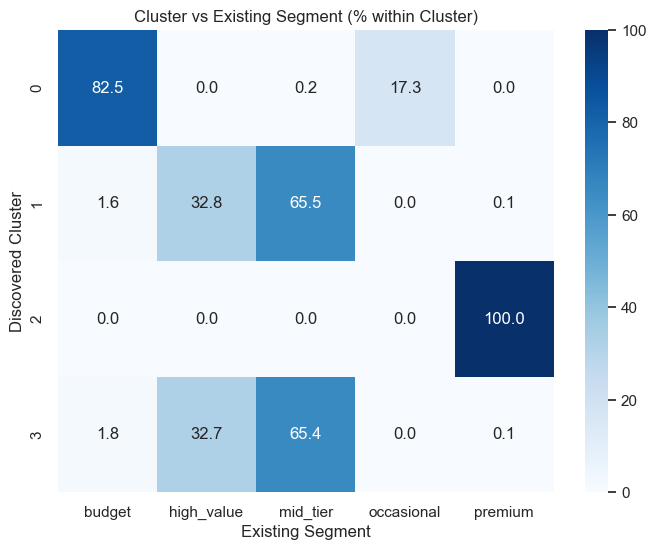

In [51]:
crosstab_pct = pd.crosstab(data_preprocess['Cluster'], raw_data['segment'], normalize = 'index') * 100

plt.figure(figsize = (8,6))
sns.heatmap(crosstab_pct, annot=True, fmt='.1f',cmap='Blues')
plt.title('Cluster vs Existing Segment (% within Cluster)')
plt.xlabel('Existing Segment')
plt.ylabel('Discovered Cluster')
plt.show()

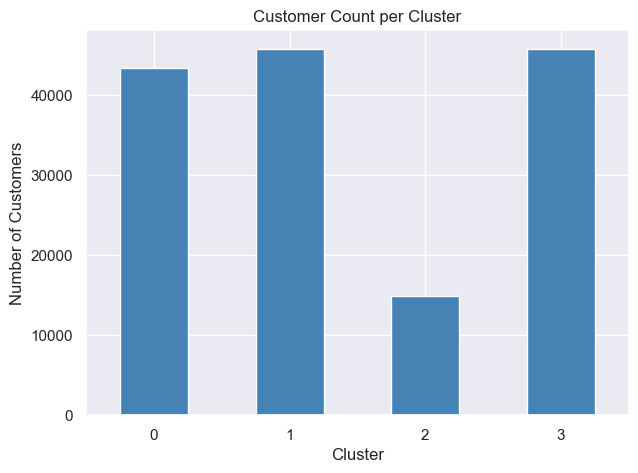

In [52]:
plt.figure(figsize = (7,5))
data_preprocess['Cluster'].value_counts().sort_index().plot(kind='bar',color='steelblue')
plt.title('Customer Count per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

The chart shows the number of customers assigned to each of the four clusters. Cluster 0,1, and 3 contain relatively large and similar customer populations, whereas Cluster 2 contain substantially fewer customers. this indicates that the customer segments are not evenly distributed and that cluster 2 represents a more specific group of customers.

# MAPPING CLUSTER NUMBER TO DESCRIPTIVE SEGMENT NAMES

In [53]:
cluster_labels = {0:'Budget & Occasional Shoppers', 1:'Frequent Mid-Spenders', 2:'Premium Customers', 3:'Occasional Big Buyers'}
data_preprocess['Cluster_Label'] = data_preprocess['Cluster'].map(cluster_labels)

In [54]:
print(data_preprocess[['Cluster','Cluster_Label']].head(10))
print(data_preprocess['Cluster_Label'].value_counts())

   Cluster                 Cluster_Label
0        1         Frequent Mid-Spenders
1        1         Frequent Mid-Spenders
2        1         Frequent Mid-Spenders
3        2             Premium Customers
4        3         Occasional Big Buyers
5        1         Frequent Mid-Spenders
6        0  Budget & Occasional Shoppers
7        1         Frequent Mid-Spenders
8        1         Frequent Mid-Spenders
9        1         Frequent Mid-Spenders
Cluster_Label
Occasional Big Buyers           45844
Frequent Mid-Spenders           45833
Budget & Occasional Shoppers    43416
Premium Customers               14907
Name: count, dtype: int64


In [55]:
raw_data['Cluster'] = data_preprocess['Cluster']
raw_data['Cluster_Label'] = data_preprocess['Cluster_Label']

In [56]:
raw_data.to_csv('customer_segments_output.csv',index=False)

In [57]:
raw_data.head()

,customer_id,segment,avg_order_value_ngn,purchase_frequency,total_orders,total_spend_ngn,last_purchase_days_ago,churn_risk,lifetime_value_ngn,preferred_category,seasonal_buyer,Cluster,Cluster_Label
0,CUST822847,mid_tier,152200.92,medium,77,115658.71,141,low,1731792.76,Fashion,False,1,Frequent Mid-Spenders
1,CUST928064,mid_tier,136582.83,medium,69,180661.70,143,medium,261129.27,Health,True,1,Frequent Mid-Spenders
2,CUST221451,high_value,388564.36,medium,51,276543.46,51,low,2537201.91,Home & Living,False,1,Frequent Mid-Spenders
3,CUST986193,premium,4344955.62,high,69,3746437.97,167,medium,4180414.32,Books & Media,True,2,Premium Customers
4,CUST422305,high_value,385518.17,medium,21,393956.62,35,low,4656929.32,Health,True,3,Occasional Big Buyers


The numerical cluster label were converted into descriptive customer segment names based on the characteristics identified during cluster profiling. this makes the results easier for business stakeholders to understand and use.

In [58]:
import os
print(os.getcwd())

C:\Users\USER


## Conclusion

This project applied K-Prototypes clustering to segment 150,000 customers in a Nigerian 
retail dataset, using both numeric (spend, order value, frequency) and categorical 
(purchase frequency, preferred category, seasonal buyer status) features. The optimal 
number of clusters was determined to be 4 using the elbow method.

The four discovered segments were:
- **Cluster 0 — Budget & Occasional Shoppers** (28.9%): Low spend and order value.
- **Cluster 1 — Frequent Mid-Spenders** (30.6%): High purchase frequency, moderate spend.
- **Cluster 2 — Premium Customers** (9.9%): Highest spend and order value by a wide margin.
- **Cluster 3 — Occasional Big Buyers** (30.6%): Low frequency, above-average spend per order.

### Validation
Comparing the discovered clusters against the dataset's pre-existing `segment` labels 
(Adjusted Rand Index = 0.46) showed moderate agreement. Notably, Cluster 2 matched the 
"premium" label almost perfectly, and Cluster 0 closely matched "budget" and "occasional" 
customers. However, the original "high_value" and "mid_tier" segments were split by the 
clustering algorithm into two new groups distinguished by **purchase frequency** rather 
than spend alone (Clusters 1 and 3).

### Business insight
This suggests the existing segmentation strategy captures spend level well but may be 
missing a behavioral dimension, how *often* a customer buys, independent of how much 
they spend per order. A business recommendation would be to incorporate purchase 
frequency into future segmentation efforts, since it identifies a real, actionable split 
within the "high_value/mid_tier" customer base (e.g., frequent smaller buyers vs. 
occasional big spenders may respond to very different marketing strategies).

Readme for Github
# Retail Customer Segmentation (Unsupervised Learning)

## Overview
This project applies unsupervised machine learning (K-Prototypes clustering) to segment 
150,000 customers in a Nigerian retail/e-commerce dataset. Unlike profiling pre-existing 
segment labels, clusters were discovered from scratch using raw customer behavior data, 
then validated against the dataset's existing `segment` column.

## Dataset
- ~150,000 customer records
- Mixed numeric and categorical features: average order value, total orders, total spend, 
  last purchase recency, lifetime value, purchase frequency, preferred product category, 
  seasonal buyer status, and an existing business-assigned `segment` label (used only 
  for validation, not training)

## Methodology
1. **EDA & Preprocessing**
   - Identified heavy right-skew in `avg_order_value_ngn` and `total_spend_ngn`, corrected 
     with `np.log1p()` transformation
   - Excluded `customer_id` and `segment` from the clustering feature set
2. **Model Selection**
   - Used K-Prototypes (handles mixed numeric + categorical data)
   - Determined optimal k=4 via the elbow method
3. **Clustering**
   - Fit final model with `n_clusters=4`, `init='Huang'`
4. **Profiling**
   - Computed mean numeric values and modal categorical values per cluster to interpret 
     each segment
5. **Validation**
   - Compared discovered clusters against the dataset's existing `segment` labels using 
     a crosstab and Adjusted Rand Index (ARI)

## Key Findings
- 4 distinct customer segments were identified: **Budget & Occasional Shoppers**, 
  **Frequent Mid-Spenders**, **Premium Customers**, and **Occasional Big Buyers**
- ARI = 0.46 moderate agreement with existing business segments
- The clustering perfectly recovered the "premium" segment and closely matched "budget"/
  "occasional" customers
- The existing "high_value" and "mid_tier" labels were restructured by the model around 
  **purchase frequency**, revealing a behavioral dimension not captured in the original 
  segmentation

## Business Recommendation
Incorporate purchase frequency into future customer segmentation, as it identifies a 
real, actionable split between frequent smaller-order buyers and occasional big buyers  two groups likely to respond differently to marketing and retention strategies.

## Tools & Libraries
Python, pandas, NumPy, scikit-learn, kmodes (KPrototypes), matplotlib, seaborn

## Files
- `retail_customer_segmentation.ipynb` — full analysis notebook